# Land-Variable RMSE Comparison Maps

This is the land companion to `1c_atm_leadtime_rmse_compare.ipynb`/`1c_ocn_leadtime_rmse_compare.ipynb`.
It reuses `1a_lnd_leadtime_acc_skill_map.ipynb`'s provenance-validated staged
land inputs (`forecast_by_case_month`, `reference`, `valid_time_by_case_month`) up
through raw seasonal loading, then computes **direct** (raw-value, non-anomaly) RMSE
between every enabled E3SM case and the land reference product, and RMSE differences
between every other enabled case and a configurable `reference_model` (always an
E3SM case here, since land has no CESM-SMYLE benchmark).

Prepared inputs reuse the `1a_lnd`/`1b_lnd` source-first hierarchy. Direct RMSE is stored separately:
`<S2D_DIAG_ROOT>/<source-or-case>/leadtime_acc/comparison/lnd/direct_rmse/<field>/`.

Direct RMSE needs an absolute-value reference. For a field whose reference is
anomaly-only (`is_anomaly=True`, e.g. C3S TWSA for `TWS`), inputs are still prepared
but the direct-RMSE, difference, and figure cells print a skip message instead of
running; use `1b_lnd_leadtime_rmse_skill_map.ipynb` for that field's normalized RMSE.


In [21]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import display

from esp_lab import land_input_cache, land_skill
from esp_lab import env_paths
from esp_lab.leadtime_prepared_cache import cache_status
from esp_lab.leadtime_plot_utils import (
    add_lead_badge,
    add_missing_map_panel,
    seasonal_label,
    style_global_map_axis,
)
from esp_lab.paths import leadtime_acc_dir
from esp_lab.utils.filename_utils import safe_token
from esp_lab.utils.netcdf_utils import atomic_to_netcdf, load_netcdf
from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Managed Dask resources

A local production run uses worker processes with the shared-node safety cap.
Rerunning this cell closes any previous notebook cluster and tracked datasets first.


In [22]:
import dask
from dask.distributed import (
    wait,
    get_client
)
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

dask.__version__

# User-adjustable Dask settings (shared login nodes are capped at four workers).
DASK_SETTINGS = {
    "enabled": True,
    "cluster_type": "local",
    "workers": 12,
    "memory_limit": "4GB",
}

dask_cfg = DaskConfig(
    cluster_type=DASK_SETTINGS["cluster_type"],
    workers=DASK_SETTINGS["workers"],
    memory_limit=DASK_SETTINGS["memory_limit"],
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(dask_cfg) if DASK_SETTINGS["enabled"] else (None, None),
)
if client is not None:
    display(client)


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Scheduler: tcp://127.0.0.1:41151
Connected workers: 4
Dashboard: http://127.0.0.1:33887/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:33887/status,
Dashboard: http://127.0.0.1:33887/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41151,Workers: 0
Dashboard: http://127.0.0.1:33887/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33617,Total threads: 1
Dashboard: http://127.0.0.1:39999/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:33459,


## User setup

Choose the land field, archives, evaluation period, cache policy, Dask resources, and
outputs here. `WORKFLOW_SETTINGS["run"]` groups the experiment and resource
choices, while `WORKFLOW_SETTINGS["regrid"]` controls target resolution, method,
and periodicity. `prepared_land.mode="auto"` with inventory identity is the normal
production setting. After an inventory run, `source_identity_mode="snapshot"` with
`prepared_land.mode="require"` provides an archive-free restart from the exact prepared
inputs. `source_identity_mode="prefer_snapshot"` is the fast default: it uses
saved source identities when available and falls back to a fresh inventory only
for inputs that have not been snapshotted yet. `smoke_mode=True` selects a small
but archive-backed two-case run. Switch back to `inventory` after raw files are
updated in place so their sizes and modification times are checked again.


In [ ]:
field = "H2OSNO" # Snow Water Equivalent (SWE, units: mm)
#field = "H2OSOI" # Soil Moisture (0-1.6 m column water, units: mm)
#field = "TWS" # Terrestrial Water Storage (TWS, units: mm)

# mode for derivation of variables choices (prepared land inputs):
# "auto": automatically determine whether to rebuild or use cached results
# "rebuild": force recomputation
# "require": require cached results and fail if not available
derivation_mode = "auto"

# True to remove the trend (default) from the data, False to keep it.
remove_trend = True

# True to force recomputation of RMSE comparison metrics, False (default) to use cached results if available
recompute_rmse = False

# Optional common processing end year. None uses the end year from
# run.initialization_years.
YEAR_END = 2011  # None
SOIL_DEPTH_RANGE_M = (0.0, 1.6) if field == "H2OSOI" else None

# The E3SM case every other enabled case is compared against. Land has no
# CESM-SMYLE benchmark, so this is always an enabled E3SM case (matching
# reference_model in 1c_atm/1c_ocn, which defaults to CESM-SMYLE instead).
reference_model = "E3SM-Reanalysis"

WORKFLOW_SETTINGS = {
    "run": {
        "smoke_mode": False,
        "initialization_years": (1980, 2018 if YEAR_END is None else int(YEAR_END)),
        "year_end": YEAR_END,
        "init_months": [5, 11],
        "climatology_years": (1981, 2010),
        "ensemble_members": [f"EN{i:02d}" for i in range(10)],
        "monthly_nlead": 24,
        "seasonal_nlead": 8,
        "detrend": remove_trend,
        # False matches 1a's fast path: file/time/member labels are checked, but
        # native-grid values are not scanned twice before regridding and writing.
        # Set True for the expensive, cell-by-cell completeness audit.
        "strict_member_completeness": False,
        "force_compute": recompute_rmse,
        "raw_model_chunks": {"Y": 3, "L": 24, "M": 2, "lat": 90, "lon": 180},
        "model_chunks": {"Y": -1, "L": 4, "M": 2, "lat": 45, "lon": 90},
        "reference_chunks": {"time": -1, "lat": 45, "lon": 90},
    },
    "regrid": {
        "target_dlat": 5.0,
        "target_dlon": 5.0,
        "method": "conservative",
        "periodic": True,
    },
}
RUN = WORKFLOW_SETTINGS["run"]
REGRID = WORKFLOW_SETTINGS["regrid"]
GRID_TAG = land_input_cache.target_grid_tag(
    REGRID["target_dlat"], REGRID["target_dlon"]
)

E3SM_CASES = {
    "E3SM-Reanalysis": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "cache_tag": "Reanalysis",
        "display_name": "E3SMv3-Reanalysis",
        "source_revision": "post_process_v1",
    },
    "E3SM-FOSIRL": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "cache_tag": "JRA55_FOSIRL",
        "display_name": "E3SMv3-FOSIRL",
        "source_revision": "post_process_v1",
    },
    "E3SM-4DEnVarOcn": {
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
        "cache_tag": "4DEnVarOcn",
        "display_name": "E3SMv3-4DEnVarOcn",
        "source_revision": "post_process_v1",
    },
}

REFERENCE_CONFIGS = {
    "H2OSNO": {
        "path": f"{env_paths.data_root()}/C3S_SWE/1x1/monthly/swe_*.nc",
        "variable": "swe", "product": "C3S_SWE",
        "documentation": "Copernicus Climate Change Service snow water equivalent",
        "source_revision": "c3s_swe_archive_2026-08-26",
        "scale": 1.0, "offset": 0.0, "output_units": "mm",
        "is_anomaly": False, "already_seasonal": False,
        "mask_negative_categorical_flags": True,
        "require_complete_calendar_months": True,
        "retain_missing_seasons": True,
        "restrict_model_to_reference_months": True,
        "require_complete_evaluation_cohort": True,
    },
    "TWS": {
        "path": f"{env_paths.data_root()}/C3S_TWSA/1x1/monthly/twsa_*.nc",
        "variable": "twsa", "product": "C3S_TWSA",
        "documentation": "C3S terrestrial water storage anomaly v1.0; doi:10.5880/GFZ.C3S_TWSA_v1.0",
        "source_revision": "c3s_twsa_v1.0_archive_2026-09-09",
        "scale": 1.0, "offset": 0.0, "output_units": "mm",
        "is_anomaly": True, "already_seasonal": False,
        "require_complete_calendar_months": True,
        "retain_missing_seasons": True,
        "restrict_model_to_reference_months": True,
        "require_complete_evaluation_cohort": False,
        "minimum_evaluation_years": 7,
    },
    "H2OSOI": {
        "path": f"{env_paths.data_root()}/CPC_SOM/monthly/soilw_*.nc",
        "variable": "soilw", "product": "CPC_Soil_Moisture_V2",
        "documentation": "https://www.cpc.ncep.noaa.gov/soilmst/descrip.htm",
        "source_revision": "cpc_soil_moisture_v2_archive_2026-08-26",
        "scale": 1.0, "offset": 0.0, "output_units": "mm",
        "is_anomaly": False, "already_seasonal": False,
        "vertical_dim": None, "layer_bounds_variable": None,
        "represented_depth_range_m": (0.0, 1.6),
        "restrict_model_to_reference_months": False,
        "require_complete_evaluation_cohort": True,
    },
}

if reference_model not in E3SM_CASES:
    raise ValueError(
        f"reference_model={reference_model!r} must be an enabled E3SM case; "
        f"enabled cases are {list(E3SM_CASES)}"
    )
    
reference_cfg = REFERENCE_CONFIGS[field]
REFERENCE_PRODUCT = reference_cfg["product"]
if REFERENCE_PRODUCT == "CONFIGURE_ME":
    raise ValueError("Configure the TWS reference product and raw-data contract")

CACHE_SETTINGS = {
    "prepared_land": {"mode": derivation_mode},  # auto, rebuild, or require
    "source_identity_mode": "prefer_snapshot",  # prefer_snapshot, inventory, snapshot, or revision
    "cleanup_temp_files": True,
    "temp_file_max_age_hours": 24.0,
}
PATHS = {
    "raw_model_root": str(env_paths.raw_model_root()),
    "staged_input_root": str(env_paths.s2d_diag_root()),
    "cache_output_root": str(env_paths.s2d_diag_root()),
    "figure_outdir": str(env_paths.figure_root()),
}
if RUN["smoke_mode"]:
    RUN.update(
        initialization_years=(2000, 2004), year_end=None, init_months=[11],
        climatology_years=(2000, 2004),
        # monthly_nlead stays at the archive's 24 months: raw files are matched
        # on their exact 24-month coverage, so a shorter value finds no inputs.
        ensemble_members=["EN00", "EN01"], seasonal_nlead=2,
    )
    print("ESP-Lab land smoke mode: two cases, one month, five years, two members/leads.")

run_year_start, run_year_end = map(int, RUN["initialization_years"])
configured_year_end = RUN.get("year_end")
processing_year_end = (
    run_year_end if configured_year_end is None else int(configured_year_end)
)
if not run_year_start <= processing_year_end <= run_year_end:
    raise ValueError(
        f"run.year_end {processing_year_end} must lie within configured "
        f"initialization years {run_year_start}-{run_year_end}"
    )
PROCESSING_YEARS = (run_year_start, processing_year_end)
if "E3SM-4DEnVarOcn" in E3SM_CASES and processing_year_end > 2011:
    raise ValueError(
        f"E3SM-4DEnVarOcn only spans 1980-2011. For multi-model comparison with 4DEnVar, "
        f"set YEAR_END = 2011 or remove 'E3SM-4DEnVarOcn' from E3SM_CASES."
    )
print(
    f"Processing initialization years: "
    f"{PROCESSING_YEARS[0]}-{PROCESSING_YEARS[1]}"
)

RAW_MODEL_ROOT = Path(PATHS["raw_model_root"])
STAGED_INPUT_ROOT = Path(PATHS["staged_input_root"])
S2D_DIAG_ROOT = Path(PATHS["cache_output_root"])
FIGURE_OUTDIR = Path(PATHS["figure_outdir"])
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

EVALUATION_PROTOCOL = (
    f"land_acc_init{PROCESSING_YEARS[0]}-{PROCESSING_YEARS[1]}_"
    f"clim{RUN['climatology_years'][0]}-{RUN['climatology_years'][1]}_"
    f"per-lead_{'detrend' if RUN['detrend'] else 'nodetrend'}"
)

REFERENCE_DISPLAY_NAMES = {
    "CPC_Soil_Moisture_V2": "CPC V2",
    "C3S_SWE": "C3S SWE",
    "C3S_TWSA": "C3S TWSA",
}
REFERENCE_DISPLAY_NAME = REFERENCE_DISPLAY_NAMES.get(
    REFERENCE_PRODUCT, REFERENCE_PRODUCT.replace("_", " "),
)
if field == "H2OSOI":
    if REFERENCE_PRODUCT == "CPC_Soil_Moisture_V2":
        REFERENCE_LEVEL_DEPTH = "0–1.6m"
        REFERENCE_CAPTION_NAME = "0–1.6m soil moisture"
    elif REFERENCE_PRODUCT == "C3S_SWE":
        REFERENCE_LEVEL_DEPTH = "0-5cm"
        REFERENCE_CAPTION_NAME = "upper ~5 cm"

init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}
MAP_STYLE = {
    "lon_ticks": [-120, -60, 0, 60, 120],
    "lat_ticks": [-60, -30, 0, 30, 60],
    "tick_length": 2.5, "tick_width": 0.5,
    "grid_linewidth": 0.35, "grid_color": "0.35",
    "grid_alpha": 0.35,
} 

# Stable output names: rerunning a field replaces its previous figures.
FIGURE_FILENAMES = {
    "H2OSNO": {
        "rmse": "fig_rmse_compare_h2osno_rmse_compare_global.png",
        "conus": "fig_rmse_compare_h2osno_rmse_compare_conus.png",
        "difference": "fig_rmse_compare_h2osno_rmse_difference_global_init{init_month:02d}.png",
    },
    "TWS": {
        "rmse": "fig_rmse_compare_tws_rmse_compare_global.png",
        "conus": "fig_rmse_compare_tws_rmse_compare_conus.png",
        "difference": "fig_rmse_compare_tws_rmse_difference_global_init{init_month:02d}.png",
    },
    "H2OSOI": {
        "rmse": "fig_rmse_compare_h2osoi_rmse_compare_global.png",
        "conus": "fig_rmse_compare_h2osoi_rmse_compare_conus.png",
        "difference": "fig_rmse_compare_h2osoi_rmse_difference_global_init{init_month:02d}.png",
    },
}
field_fig_names = FIGURE_FILENAMES.get(field, {
    "conus": f"fig_rmse_compare_{field.lower()}_rmse_compare_conus.png",
    "rmse": f"fig_rmse_compare_{field.lower()}_rmse_compare_global.png",
    "difference": f"fig_rmse_compare_{field.lower()}_rmse_difference_global_init{{init_month:02d}}.png",
})

FIGURE_SETTINGS = {
    "rmse": {
        "filename": field_fig_names["rmse"],
        "max_leads": 7,
        "cmap": "YlOrRd",
        "color_interval": 0.1, "color_min": 0.0, "color_max": 2.0,
        "color_cutoff": 0.5,
        "font_size": 18,
        "axis_label_font_scale": 0.75, "lead_label_font_scale": 0.75,
        "title_font_scale": 1.20, "colorbar_tick_font_scale": 0.80,
        "figsize": (24, 18),  # width, height in inches
        "layout_rect": (0.0, 0.075, 1.0, 0.96),
        "subplot_bottom": 0.09, "subplot_hspace": 0.06,
        "subplot_wspace": 0.025, "section_gap": 0.035,
        "month_header_y": 0.962, "divider_y0": 0.08,
        "divider_y1": 0.95, "divider_color": "0.25",
        "divider_linewidth": 1.0, "font_weight": "bold",
        "colorbar_rect": (0.28, 0.025, 0.44, 0.015),
        "colorbar_label": "RMSE", "colorbar_orientation": "horizontal",
        "title_y": 0.995, "dpi": 300,
    },
    "difference": {
        "filename": field_fig_names["difference"],
        "color_interval": 0.05, "color_min": -1.0, "color_max": 1.0,
        "color_cutoff": 0.25, "cmap": "blue2red",
        "figsize": (18.0, 16.0),  # height used; width scales with the columns
        "column_width": 5.0, "extra_width": 1.0,
        "font_size": 18,
        "title_template": "{variable} RMSE differences: experiments minus {control}, {trend} (ref: {reference})",
        "colorbar_label": r"${\Delta}$RMSE",
        "title_font_scale": 1.1, "month_header_font_scale": 1.0,
        "axis_label_font_scale": 0.75, "lead_label_font_scale": 0.75,
        "colorbar_tick_font_scale": 0.8, "title_y": 0.992,
        "layout_edges": (0.035, 0.10, 0.995, 0.91),
        "month_header_y": 0.945, "divider_y0": 0.085,
        "divider_y1": 0.91, "divider_color": "0.25",
        "divider_linewidth": 1.0, "font_weight": "bold",
        "colorbar_orientation": "horizontal", "layout_pad": 0.3,
        "layout_h_pad": 0.15, "layout_w_pad": 0.1,
        "subplot_top": 0.91, "subplot_bottom": 0.10,
        "subplot_hspace": 0.025, "subplot_wspace": 0.02,
        "section_gap": 0.04,
        "colorbar_rect": (0.30, 0.025, 0.40, 0.014), "dpi": 300,
    },
}

# Direct RMSE (model minus observation, bias included) needs an absolute-value
# reference. Anomaly-only references (C3S_TWSA for TWS) cannot be compared with
# raw model storage, so the direct-RMSE cells (computation, differences and
# figures) are skipped for them; inputs are still prepared. 1b_lnd covers
# these fields with anomaly-based normalized RMSE.
DIRECT_RMSE_UNDEFINED = bool(reference_cfg["is_anomaly"])
SKIP_MESSAGE = (
    f"{field} has an anomaly-only reference ({REFERENCE_PRODUCT}); direct RMSE is "
    "not defined — see 1b_lnd_leadtime_rmse_skill_map.ipynb. Skipping this direct-RMSE cell."
)
if DIRECT_RMSE_UNDEFINED:
    print(SKIP_MESSAGE)


## Prepare or reuse analysis-ready inputs

Planning is independent for the reference and every model case/month. Inventory mode
records exact file identities and snapshots before any expensive preparation. Snapshot
mode never resolves raw paths and requires compatible prepared caches. Dataset contracts
validate dimensions, members, years, grid, units, depth treatment, and provenance.


In [24]:
prepared_mode = CACHE_SETTINGS["prepared_land"]["mode"]
if prepared_mode not in {"auto", "rebuild", "require"}:
    raise ValueError("prepared_land.mode must be 'auto', 'rebuild', or 'require'")
source_identity_mode = CACHE_SETTINGS["source_identity_mode"]
if source_identity_mode not in {"prefer_snapshot", "inventory", "snapshot", "revision"}:
    raise ValueError("source_identity_mode must be prefer_snapshot, inventory, snapshot, or revision")
if source_identity_mode == "snapshot" and prepared_mode != "require":
    raise ValueError("Snapshot mode requires prepared_land.mode='require'")

if "workflow_resources" not in globals():
    raise RuntimeError("Run the managed Dask setup cell before preparation")
netcdf_write_options = {
    "cleanup_temporary": CACHE_SETTINGS["cleanup_temp_files"],
    "temp_file_max_age_hours": CACHE_SETTINGS["temp_file_max_age_hours"],
}
years = np.arange(PROCESSING_YEARS[0], PROCESSING_YEARS[1] + 1)
target_grid = land_input_cache.target_grid(
    REGRID["target_dlat"], REGRID["target_dlon"]
)
SOURCE_SNAPSHOT_DIR = S2D_DIAG_ROOT / "tmp" / "source_inventory_snapshots" / "land"
if not SOURCE_SNAPSHOT_DIR.exists() and (S2D_DIAG_ROOT / "source_inventory_snapshots" / "land").exists():
    SOURCE_SNAPSHOT_DIR = S2D_DIAG_ROOT / "source_inventory_snapshots" / "land"
DEPTH_TOKEN = land_skill.land_depth_token(field, SOIL_DEPTH_RANGE_M)
reference_path = land_skill.reference_land_input_path(
    STAGED_INPUT_ROOT, REFERENCE_PRODUCT, field, GRID_TAG,
    depth_range_m=SOIL_DEPTH_RANGE_M,
)
model_input_paths = {
    case_name: {
        init_month: land_skill.staged_land_input_path(
            STAGED_INPUT_ROOT, case_cfg["cache_tag"], field, GRID_TAG,
            init_month=init_month, depth_range_m=SOIL_DEPTH_RANGE_M,
        )
        for init_month in RUN["init_months"]
    }
    for case_name, case_cfg in E3SM_CASES.items()
}

reference_files = []
reference_identity_kwargs = {
    "logical_identity": {
        "product": REFERENCE_PRODUCT, "variable": reference_cfg["variable"],
        "field": field, "path_pattern": reference_cfg["path"],
    },
    "source_revision": reference_cfg["source_revision"],
    "inventory_root": Path(reference_cfg["path"]).parent,
    "snapshot_dir": SOURCE_SNAPSHOT_DIR,
}
if source_identity_mode == "prefer_snapshot":
    try:
        reference_raw_identity = land_input_cache.raw_source_identity(
            paths=[], mode="snapshot", **reference_identity_kwargs
        )
        print("Using saved source identity for reference")
    except (RuntimeError, ValueError):
        reference_files = land_input_cache.resolve_reference_files(reference_cfg["path"])
        reference_raw_identity = land_input_cache.raw_source_identity(
            paths=reference_files, mode="inventory", **reference_identity_kwargs
        )
        print("Created source-identity snapshot for reference")
else:
    if source_identity_mode == "inventory":
        reference_files = land_input_cache.resolve_reference_files(reference_cfg["path"])
    reference_raw_identity = land_input_cache.raw_source_identity(
        paths=reference_files, mode=source_identity_mode, **reference_identity_kwargs
    )
reference_month_policy = (
    "complete centered 3-month windows; retain explicit missing seasons"
    if reference_cfg.get("require_complete_calendar_months", False)
    else "all seasonal center months"
)
reference_expected_attrs = land_input_cache.expected_attrs(
    field=field, source_kind="reference", source_name=REFERENCE_PRODUCT,
    source_data_identity=reference_raw_identity,
    initialization_years=PROCESSING_YEARS,
    climatology_years=RUN["climatology_years"],
    ensemble_members=RUN["ensemble_members"], monthly_nlead=RUN["monthly_nlead"],
    target_grid_name=GRID_TAG, regridding_method=REGRID["method"],
    regridding_periodic=REGRID["periodic"],
    output_units=reference_cfg["output_units"],
    reference_is_anomaly=reference_cfg["is_anomaly"],
    depth_range_m=SOIL_DEPTH_RANGE_M,
    reference_month_policy=reference_month_policy,
)
reference_ok, reference_reason = land_input_cache.prepared_cache_status(
    reference_path, reference_expected_attrs, grid=target_grid
)
if prepared_mode == "require" and not reference_ok:
    raise FileNotFoundError(f"Required prepared reference is unavailable: {reference_reason}")
if prepared_mode == "rebuild" or not reference_ok:
    if not reference_files:
        reference_files = land_input_cache.resolve_reference_files(reference_cfg["path"])
    print(f"Preparing reference ({reference_reason}): {reference_path}")
    land_input_cache.prepare_reference_cache(
        paths=reference_files, cfg=reference_cfg, field=field,
        depth_range_m=SOIL_DEPTH_RANGE_M, grid=target_grid,
        periodic=REGRID["periodic"],
        expected=reference_expected_attrs, output_path=reference_path,
        write_options=netcdf_write_options,
    )
else:
    print("Reusing prepared reference:", reference_path)

reference_dataset = xr.open_dataset(reference_path, chunks=RUN["reference_chunks"])
workflow_resources.track(reference_dataset)
land_input_cache.validate_dataset(
    reference_dataset, reference_expected_attrs, grid=target_grid
)
reference = reference_dataset[field]
reference_is_anomaly = reference_cfg["is_anomaly"]
reference_data_identity = land_input_cache.prepared_data_identity(
    reference_expected_attrs
)

model_expected_attrs = {}
model_data_identity_by_case_month = {}
for case_name, case_cfg in E3SM_CASES.items():
    model_expected_attrs[case_name] = {}
    model_data_identity_by_case_month[case_name] = {}
    for init_month in RUN["init_months"]:
        model_files = []
        model_identity_kwargs = {
            "logical_identity": {
                "case": case_name, "case_prefix": case_cfg["case_prefix"],
                "field": field, "init_month": init_month,
                "years": list(map(int, years)),
                "members": list(RUN["ensemble_members"]),
                "monthly_nlead": int(RUN["monthly_nlead"]),
            },
            "source_revision": case_cfg["source_revision"],
            "inventory_root": RAW_MODEL_ROOT,
            "snapshot_dir": SOURCE_SNAPSHOT_DIR,
        }
        if source_identity_mode == "prefer_snapshot":
            try:
                raw_identity = land_input_cache.raw_source_identity(
                    paths=[], mode="snapshot", **model_identity_kwargs
                )
                print(f"Using saved source identity: {case_name}, init={init_month}")
            except (RuntimeError, ValueError):
                model_files = land_input_cache.resolve_model_files(
                    data_dir=RAW_MODEL_ROOT, case_prefix=case_cfg["case_prefix"],
                    members=RUN["ensemble_members"], years=years,
                    init_month=init_month, field=field, nlead=RUN["monthly_nlead"],
                )
                raw_identity = land_input_cache.raw_source_identity(
                    paths=model_files, mode="inventory", **model_identity_kwargs
                )
                print(f"Created source-identity snapshot: {case_name}, init={init_month}")
        else:
            if source_identity_mode == "inventory":
                model_files = land_input_cache.resolve_model_files(
                    data_dir=RAW_MODEL_ROOT, case_prefix=case_cfg["case_prefix"],
                    members=RUN["ensemble_members"], years=years,
                    init_month=init_month, field=field, nlead=RUN["monthly_nlead"],
                )
            raw_identity = land_input_cache.raw_source_identity(
                paths=model_files, mode=source_identity_mode, **model_identity_kwargs
            )
        expected = land_input_cache.expected_attrs(
            field=field, source_kind="model", source_name=case_name,
            source_data_identity=raw_identity, case_prefix=case_cfg["case_prefix"],
            init_month=init_month, initialization_years=PROCESSING_YEARS,
            climatology_years=RUN["climatology_years"],
            ensemble_members=RUN["ensemble_members"], monthly_nlead=RUN["monthly_nlead"],
            target_grid_name=GRID_TAG, regridding_method=REGRID["method"],
            regridding_periodic=REGRID["periodic"],
            output_units=reference_cfg["output_units"],
            reference_is_anomaly=reference_cfg["is_anomaly"],
            depth_range_m=SOIL_DEPTH_RANGE_M,
            reference_month_policy=reference_month_policy,
        )
        path = model_input_paths[case_name][init_month]
        compatible, reason = land_input_cache.prepared_cache_status(
            path, expected, grid=target_grid
        )
        if prepared_mode == "require" and not compatible:
            raise FileNotFoundError(f"Required prepared model input {path} is unavailable: {reason}")
        if prepared_mode == "rebuild" or not compatible:
            print(f"Preparing {case_name}, init={init_month} ({reason}): {path}")
            land_input_cache.prepare_model_cache(
                data_dir=RAW_MODEL_ROOT, case_prefix=case_cfg["case_prefix"],
                members=RUN["ensemble_members"], years=years, init_month=init_month,
                field=field, monthly_nlead=RUN["monthly_nlead"],
                monthly_chunks=RUN["raw_model_chunks"],
                depth_range_m=SOIL_DEPTH_RANGE_M, reference=reference,
                restrict_to_reference_months=reference_cfg.get(
                    "restrict_model_to_reference_months", False
                ),
                climatology_years=RUN["climatology_years"],
                strict_member_completeness=RUN["strict_member_completeness"],
                grid=target_grid, expected=expected, output_path=path,
                periodic=REGRID["periodic"],
                write_options=netcdf_write_options,
                resolved_files=model_files or None,
            )
        else:
            print(f"Reusing prepared model input: {case_name}, init={init_month}: {path}")
        model_expected_attrs[case_name][init_month] = expected
        model_data_identity_by_case_month[case_name][init_month] = (
            land_input_cache.prepared_data_identity(expected)
        )

print(f"Prepared-input mode: {prepared_mode}; source identity: {source_identity_mode}")

Using saved source identity for reference
Reusing prepared reference: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/observations/leadtime_acc/prepared_skill/lnd/H2OSNO/C3S_SWE_H2OSNO_seasonal_5x5deg_cell_centered.nc
Using saved source identity: E3SM-Reanalysis, init=5
Reusing prepared model input: E3SM-Reanalysis, init=5: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/prepared_skill/lnd/H2OSNO/Reanalysis_init05_H2OSNO_seasonal_5x5deg_cell_centered.nc
Using saved source identity: E3SM-Reanalysis, init=11
Reusing prepared model input: E3SM-Reanalysis, init=11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/prepared_skill/lnd/H2OSNO/Reanalysis_init11_H2OSNO_seasonal_5x5deg_cell_centered.nc
Using saved source identity: E3SM-FOSIRL, init=5
Reusing prepared model input: E3SM-FOSIRL, init=5: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/prepared_skill/lnd/H2OSNO/JRA55_FOSIRL_init05_H2OSNO_seasonal_5x5deg_cell_centered.nc
Using saved source identity: E3S

In [25]:
forecast_by_case_month = {}
valid_time_by_case_month = {}
expected_years_by_case_month = {}
for case_name, case_cfg in E3SM_CASES.items():
    forecast_by_case_month[case_name] = {}
    valid_time_by_case_month[case_name] = {}
    expected_years_by_case_month[case_name] = {}
    for init_month in RUN["init_months"]:
        path = model_input_paths[case_name][init_month]
        ds = xr.open_dataset(path, chunks=RUN["model_chunks"])
        workflow_resources.track(ds)
        land_input_cache.validate_dataset(
            ds, model_expected_attrs[case_name][init_month], grid=target_grid
        )
        forecast = ds[field]
        land_skill.validate_land_reference_compatibility(forecast, reference)
        forecast, valid_time, dropped_leads = land_skill.retain_valid_seasonal_leads(
            forecast, ds.time
        )
        valid_time = valid_time.load()
        expected_years = land_skill.validate_hindcast_evaluation_setup(
            forecast, valid_time, init_month=init_month,
            initialization_years=PROCESSING_YEARS,
            expected_members=RUN["ensemble_members"],
            climatology_years=RUN["climatology_years"],
            require_complete_member_grid=RUN["strict_member_completeness"],
        )
        forecast_by_case_month[case_name][init_month] = forecast
        valid_time_by_case_month[case_name][init_month] = valid_time
        expected_years_by_case_month[case_name][init_month] = expected_years
        print("Validated:", case_name, init_month, path, "dropped leads:", dropped_leads)

VALID_LEADS_BY_MONTH = {}
for init_month in RUN["init_months"]:
    lead_coordinates = {
        tuple(forecast_by_case_month[case][init_month].L.values.tolist())
        for case in E3SM_CASES
    }
    if len(lead_coordinates) != 1:
        raise ValueError(
            f"Models do not share valid leads for init={init_month}: {lead_coordinates}"
        )
    VALID_LEADS_BY_MONTH[init_month] = list(next(iter(lead_coordinates)))
print("Valid seasonal leads by initialization month:", VALID_LEADS_BY_MONTH)

Validated: E3SM-Reanalysis 5 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/prepared_skill/lnd/H2OSNO/Reanalysis_init05_H2OSNO_seasonal_5x5deg_cell_centered.nc dropped leads: [24]
Validated: E3SM-Reanalysis 11 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/prepared_skill/lnd/H2OSNO/Reanalysis_init11_H2OSNO_seasonal_5x5deg_cell_centered.nc dropped leads: []
Validated: E3SM-FOSIRL 5 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/prepared_skill/lnd/H2OSNO/JRA55_FOSIRL_init05_H2OSNO_seasonal_5x5deg_cell_centered.nc dropped leads: [24]
Validated: E3SM-FOSIRL 11 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/prepared_skill/lnd/H2OSNO/JRA55_FOSIRL_init11_H2OSNO_seasonal_5x5deg_cell_centered.nc dropped leads: []
Validated: E3SM-4DEnVarOcn 5 /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/prepared_skill/lnd/H2OSNO/4DEnVarOcn_init05_H2OSNO_seasonal_5x5deg_cell_centered.nc dropped leads: [24]
Validated: E3SM-4DEnVarOcn 

## Compute RMSE

Unlike `1a_lnd`'s ACC metric (anomaly-based, after lead-dependent drift removal), direct
RMSE compares raw model values against the raw land reference, following the same
`workflows.leadtime_skill.rmse_comparison.compute_direct_rmse` used by
`1c_atm_leadtime_rmse_compare.ipynb`/`1c_ocn_leadtime_rmse_compare.ipynb`. No
finite-ensemble significance test is computed: every enabled E3SM land case uses the
same ensemble size, so resampling `reference_model`'s ensemble down to another case's
size has no variance (see `1c_atm`'s cell for the same limitation when its
`reference_model` is an E3SM case instead of CESM-SMYLE).


In [26]:
%%time
if DIRECT_RMSE_UNDEFINED:
    print(SKIP_MESSAGE)
else:
    from workflows.leadtime_skill import rmse_comparison as rmse_compare_helper

    UNIT_CONVERSION_VERSION = "leadtime_rmse_units_v1"
    TARGET_GRID_IDENTITY = GRID_TAG

    direct_rmse_by_case_month = {}

    for case_name in E3SM_CASES:
        direct_rmse_by_case_month[case_name] = {}

        for init_month in RUN["init_months"]:
            model_da = forecast_by_case_month[case_name][init_month]
            model_time = valid_time_by_case_month[case_name][init_month]
            common_years = [int(str(y)[:4]) for y in model_da["Y"].values]

            out_dir = leadtime_acc_dir(
                E3SM_CASES[case_name]["cache_tag"], "comparison", "lnd", "direct_rmse", field,
                root=S2D_DIAG_ROOT,
            )
            out_dir.mkdir(parents=True, exist_ok=True)
            year_tag = rmse_compare_helper.compact_year_tag(common_years)
            out_nc = out_dir / (
                f"{E3SM_CASES[case_name]['cache_tag']}_{field}_direct_rmse_"
                f"init{init_month:02d}_years_{year_tag}.nc"
            )

            expected_attrs = rmse_compare_helper.direct_rmse_cache_attrs(
                source=case_name, source_data_identity=model_data_identity_by_case_month[case_name][init_month],
                case_prefix=E3SM_CASES[case_name]["case_prefix"], variable=field,
                init_month=init_month, verification_years=common_years,
                observation_product=REFERENCE_PRODUCT, observation_variable=reference_cfg["variable"],
                observation_data_identity=reference_data_identity, target_grid=TARGET_GRID_IDENTITY,
                regridding_method=REGRID["method"], ensemble_member_count=len(RUN["ensemble_members"]),
                lead_values=rmse_compare_helper.DIRECT_RMSE_LEADS[:model_da.sizes["L"]],
                unit_conversion_version=UNIT_CONVERSION_VERSION,
            )
            compatible, reason = cache_status(
                out_nc, expected_attrs=expected_attrs,
                required_variables=("rmse", "bias", "mae", "n_years"),
            )
            if compatible and not RUN["force_compute"]:
                ds_rmse = rmse_compare_helper.normalize_direct_rmse_leads(load_netcdf(out_nc))
            else:
                print(f"Recomputing {out_nc}: {reason}")
                ds_rmse = rmse_compare_helper.compute_direct_rmse(
                    model_da=model_da, obs_da=reference, model_time=model_time,
                    common_years=common_years, field=field, units=reference_cfg["output_units"],
                    lead_coord=rmse_compare_helper.DIRECT_RMSE_LEADS[:model_da.sizes["L"]],
                ).compute()
                ds_rmse.attrs.update(expected_attrs)
                atomic_to_netcdf(ds_rmse, out_nc, **netcdf_write_options)

            direct_rmse_by_case_month[case_name][init_month] = ds_rmse
            print(case_name, init_month, "->", out_nc)

    print("Finished direct-RMSE calculation.")

E3SM-Reanalysis 5 -> /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/comparison/lnd/direct_rmse/H2OSNO/Reanalysis_H2OSNO_direct_rmse_init05_years_1980-2011_ny32.nc
E3SM-Reanalysis 11 -> /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/leadtime_acc/comparison/lnd/direct_rmse/H2OSNO/Reanalysis_H2OSNO_direct_rmse_init11_years_1980-2011_ny32.nc
E3SM-FOSIRL 5 -> /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/comparison/lnd/direct_rmse/H2OSNO/JRA55_FOSIRL_H2OSNO_direct_rmse_init05_years_1980-2011_ny32.nc
E3SM-FOSIRL 11 -> /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/leadtime_acc/comparison/lnd/direct_rmse/H2OSNO/JRA55_FOSIRL_H2OSNO_direct_rmse_init11_years_1980-2011_ny32.nc
E3SM-4DEnVarOcn 5 -> /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/comparison/lnd/direct_rmse/H2OSNO/4DEnVarOcn_H2OSNO_direct_rmse_init05_years_1980-2011_ny32.nc
E3SM-4DEnVarOcn 11 -> /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/leadtime_acc/comparison/lnd/direct_rm

## RMSE differences relative to `reference_model`

Every other enabled E3SM case minus `reference_model`. Negative values mean the
experiment case has lower (better) direct RMSE than `reference_model`.


In [27]:
%%time
if DIRECT_RMSE_UNDEFINED:
    print(SKIP_MESSAGE)
else:
    direct_rmse_diff_by_case_month = {}

    for case_name in E3SM_CASES:
        if case_name == reference_model:
            continue
        direct_rmse_diff_by_case_month[case_name] = {}

        for init_month in RUN["init_months"]:
            if init_month not in direct_rmse_by_case_month[reference_model]:
                continue
            ds_diff = rmse_compare_helper.direct_rmse_difference(
                direct_rmse_by_case_month[case_name][init_month],
                direct_rmse_by_case_month[reference_model][init_month],
            )
            ds_diff.attrs["description"] = (
                f"Direct RMSE difference and ratio relative to {reference_model}. "
                f"Negative rmse_diff or rmse_ratio < 1 indicates smaller RMSE than {reference_model}."
            )
            ds_diff.attrs["field"] = field
            direct_rmse_diff_by_case_month[case_name][init_month] = ds_diff
            print(f"{case_name} minus {reference_model}, init_month={init_month}")

    print("Finished direct-RMSE difference calculation.")

E3SM-FOSIRL minus E3SM-Reanalysis, init_month=5
E3SM-FOSIRL minus E3SM-Reanalysis, init_month=11
E3SM-4DEnVarOcn minus E3SM-Reanalysis, init_month=5
E3SM-4DEnVarOcn minus E3SM-Reanalysis, init_month=11
Finished direct-RMSE difference calculation.
CPU times: user 18.1 ms, sys: 3.39 ms, total: 21.4 ms
Wall time: 20.4 ms


## Global RMSE figure

This follows the multi-panel style of `1b_lnd_leadtime_rmse_skill_map.ipynb` and `1c_atm_leadtime_rmse_compare.ipynb`: rows are native seasonal leads, columns are E3SM cases grouped under the configured initialization-month headers, and only the outer axes carry latitude/longitude labels.


Auto color range for direct RMSE (H2OSNO): 0.0 to 50.65
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_rmse_compare_h2osno_rmse_compare_global.png


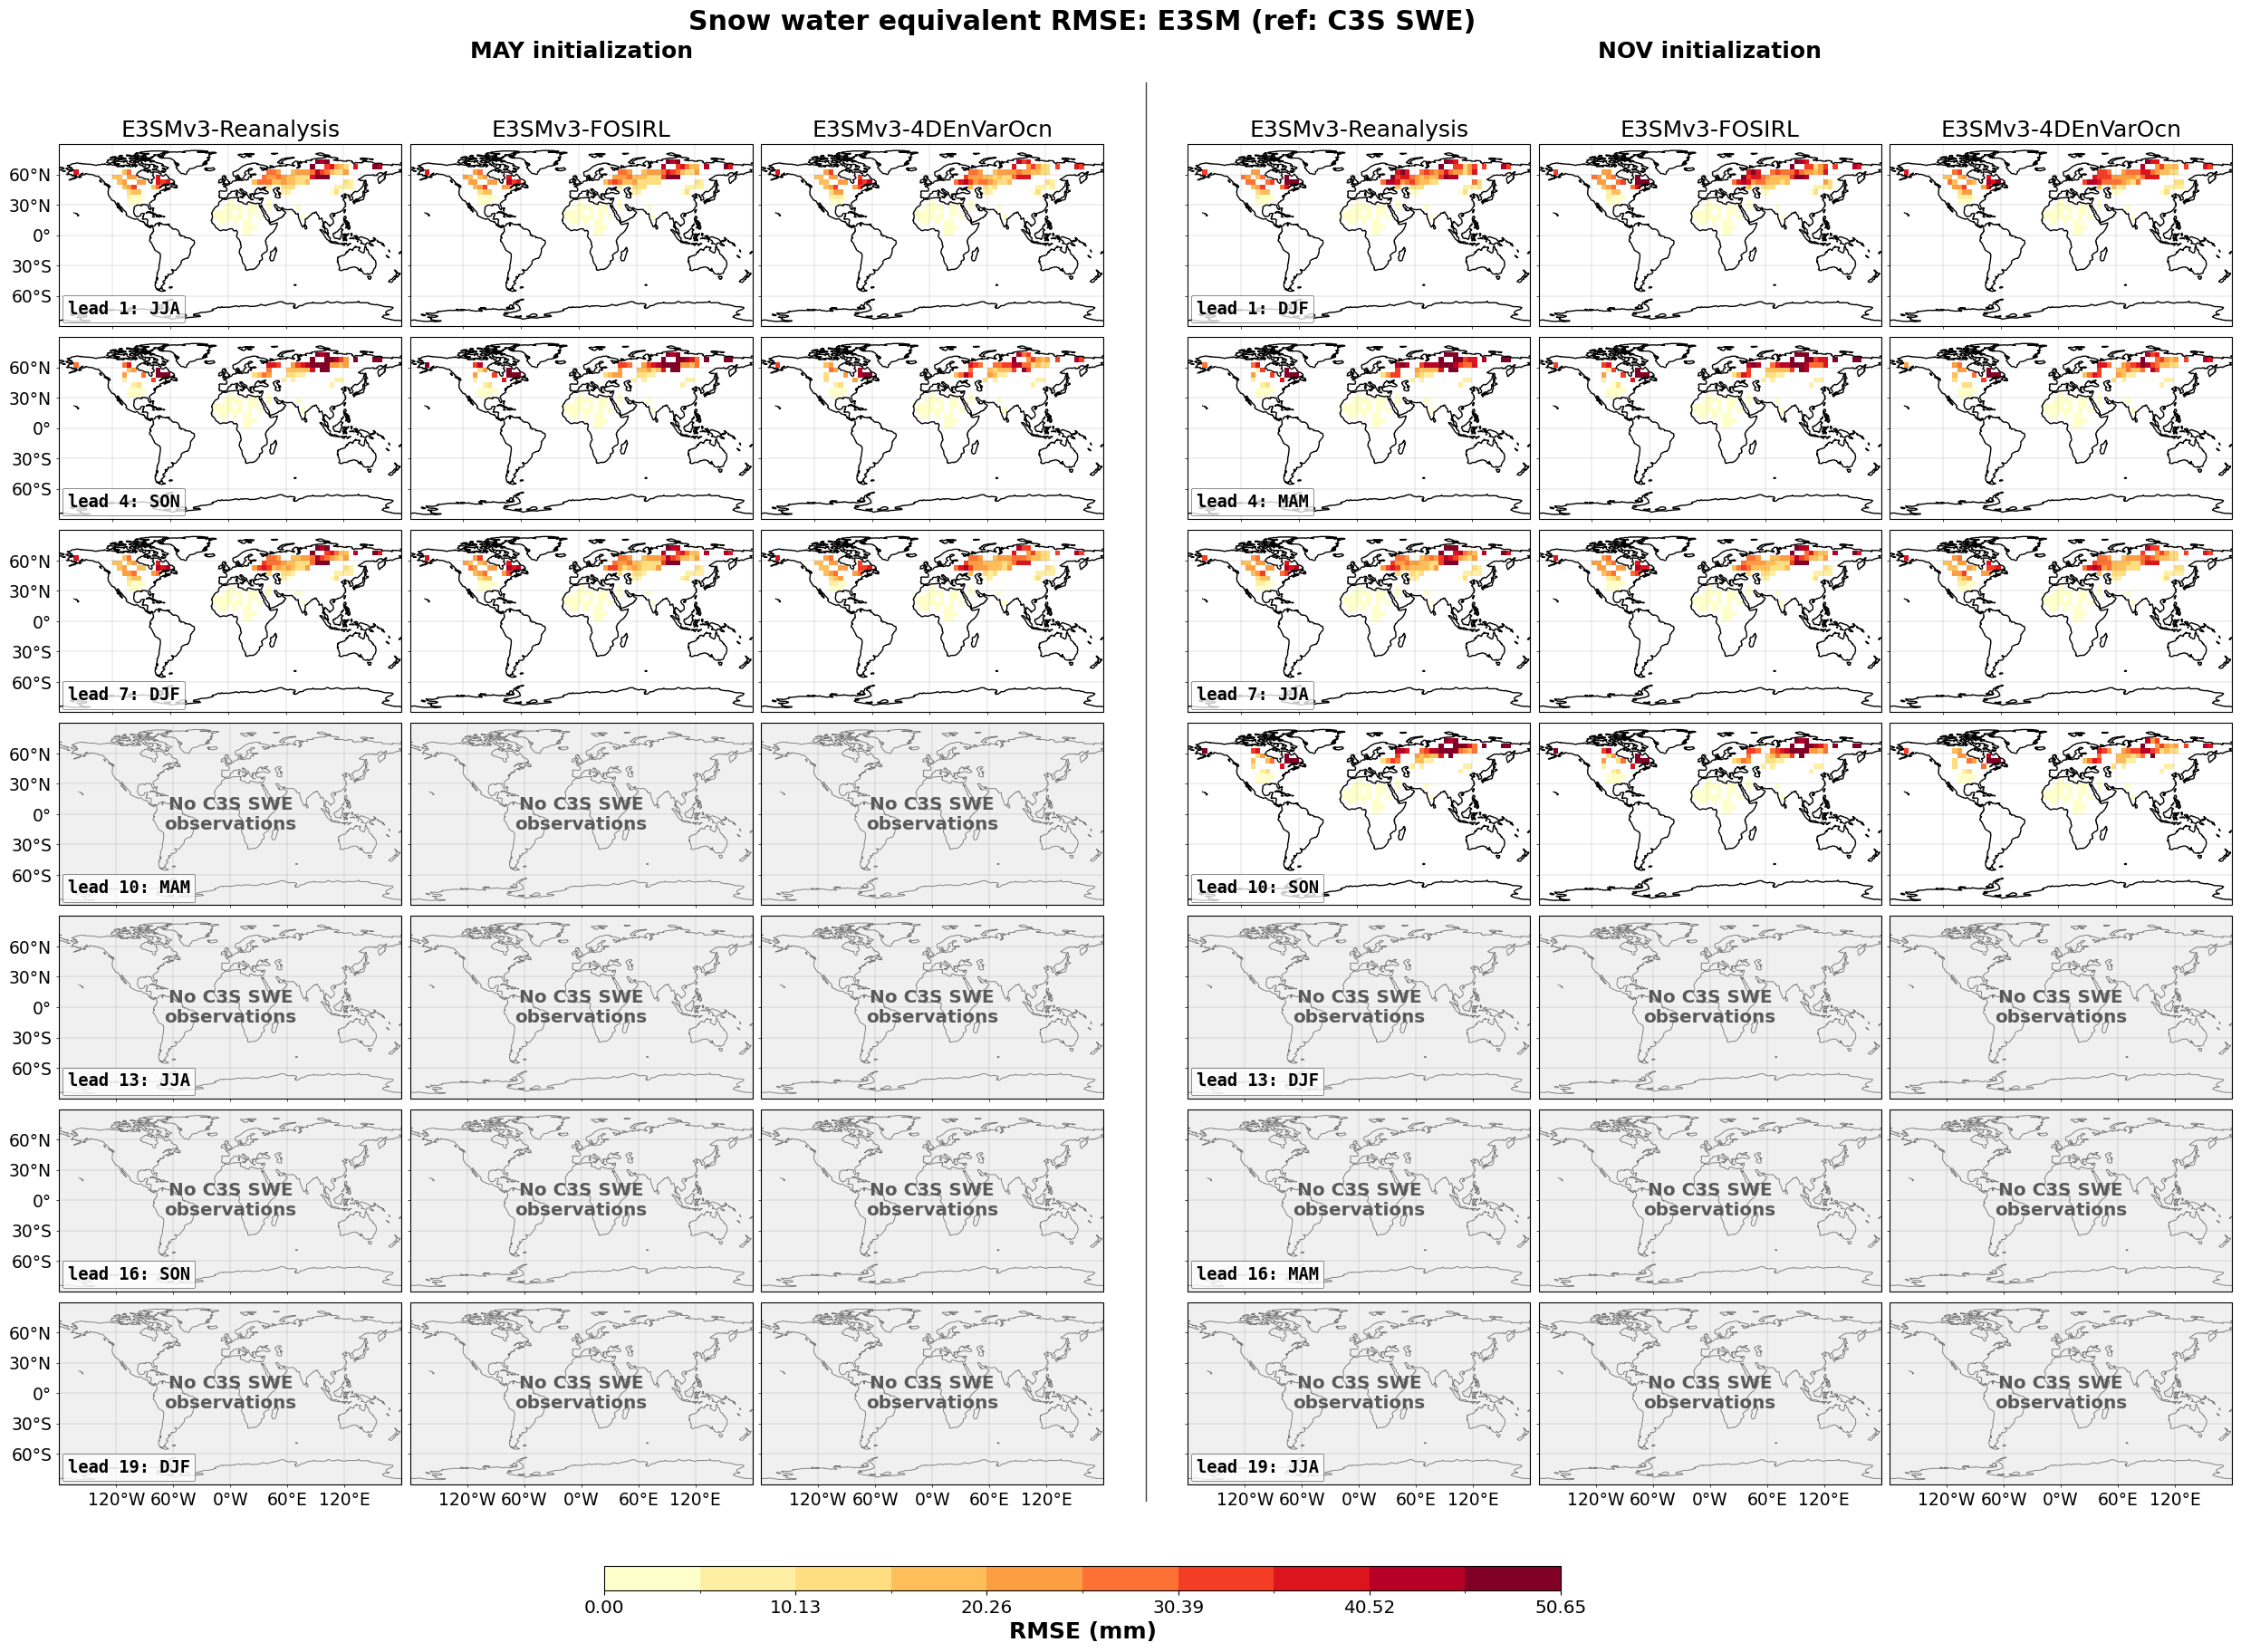

In [28]:
if DIRECT_RMSE_UNDEFINED:
    print(SKIP_MESSAGE)
else:
    import cartopy.crs as ccrs

    from esp_lab.utils import mapplot_utils as maps
    from esp_lab.utils import mov_utils as mov

    spec = land_skill.get_land_variable_spec(field)

    VARIABLE_DISPLAY_NAME = spec.plot_name
    VARIABLE_TITLE_CONTEXT = (
        f"{VARIABLE_DISPLAY_NAME} ({REFERENCE_LEVEL_DEPTH})"
        if field == "H2OSOI" else VARIABLE_DISPLAY_NAME
    )
    VARIABLE_DIFFERENCE_CONTEXT = (
        f"{VARIABLE_DISPLAY_NAME} ({REFERENCE_LEVEL_DEPTH})"
        if field == "H2OSOI" else VARIABLE_DISPLAY_NAME
    )
    VARIABLE_CAPTION_NAME = (
        REFERENCE_CAPTION_NAME if field == "H2OSOI"
        else "total water storage" if field == "TWS"
        else VARIABLE_DISPLAY_NAME.lower()
    )

    PLOT = FIGURE_SETTINGS["rmse"]

    case_display_names = {
        case_name: case_cfg.get("display_name", case_name)
        for case_name, case_cfg in E3SM_CASES.items()
    }

    column_specs = [
        (init_month, case_name)
        for init_month in RUN["init_months"]
        for case_name in E3SM_CASES
        if init_month in direct_rmse_by_case_month.get(case_name, {})
    ]
    FULL_SEASONAL_LEADS = list(range(3, RUN["monthly_nlead"], 3))[
        : min(RUN["seasonal_nlead"], PLOT["max_leads"])
    ]
    plot_leads_by_month = {
        month: FULL_SEASONAL_LEADS for month in RUN["init_months"]
    }
    if not column_specs or not any(plot_leads_by_month.values()):
        raise RuntimeError("No common case/month/lead combinations are available for plotting")

    rmse_by_case_month = {}
    for init_month, case_name in column_specs:
        skill = direct_rmse_by_case_month[case_name][init_month]
        rmse_by_case_month[(init_month, case_name)] = skill.rmse.where(skill.n_years >= 3)

    # Direct RMSE has no fixed natural scale (unlike normalized RMSE, it is in the
    # field's own physical units), so the color range is computed from the actual
    # data rather than a hardcoded guess -- a fixed 0-1 range silently saturates
    # (and misleadingly looks uniform) for fields like H2OSOI, where RMSE over a
    # 1.6 m soil column is commonly tens of millimeters.
    finite_rmse_values = np.concatenate([
        np.asarray(da.values, dtype=float)[np.isfinite(da.values)]
        for da in rmse_by_case_month.values()
    ])
    if finite_rmse_values.size == 0:
        raise RuntimeError("No finite direct-RMSE values are available to plot.")
    auto_color_max = max(float(np.nanpercentile(finite_rmse_values, 95)), 1e-6)
    auto_color_interval = auto_color_max / 10.0
    PLOT = dict(PLOT, color_min=0.0, color_max=auto_color_max, color_interval=auto_color_interval)
    print(f"Auto color range for direct RMSE ({field}): 0.0 to {auto_color_max:.4g}")

    nrows = max(map(len, plot_leads_by_month.values()))
    ncols = len(column_specs)
    projection = ccrs.PlateCarree()
    fig = plt.figure(figsize=PLOT["figsize"])
    mappable = None

    for row in range(nrows):
        for col, (init_month, case_name) in enumerate(column_specs):
            month_leads = plot_leads_by_month[init_month]
            subplot = row * ncols + col + 1
            lead = month_leads[row]
            skill = direct_rmse_by_case_month[case_name][init_month]
            title = case_display_names.get(case_name, case_name) if row == 0 else ""
            if lead in skill.L.values:
                ax, mappable = maps.map_pcolor_global_subplot(
                    fig, rmse_by_case_month[(init_month, case_name)].sel(L=lead),
                    skill.lon, skill.lat,
                    PLOT["color_interval"], PLOT["color_min"], PLOT["color_max"],
                    title, nrows, ncols, subplot, projection,
                    cmap=PLOT["cmap"], cutoff=PLOT["color_cutoff"],
                    fontsize=PLOT["font_size"],
                )
            else:
                ax = add_missing_map_panel(
                    fig, nrows=nrows, ncols=ncols, subplot=subplot, title=title,
                    message=f"No {REFERENCE_DISPLAY_NAME}\nobservations",
                    font_size=PLOT["font_size"],
                )
            style_global_map_axis(
                ax, row=row, column=col, nrows=nrows,
                label_size=PLOT["font_size"] * PLOT["axis_label_font_scale"],
                style=MAP_STYLE,
            )
            if col == 0 or (col > 0 and column_specs[col - 1][0] != init_month):
                display_lead = int(lead) - 2
                add_lead_badge(
                    ax, f"lead {display_lead}: {seasonal_label(init_month, display_lead)}",
                    font_size=PLOT["font_size"] * PLOT["lead_label_font_scale"],
                )

    field_units = reference_cfg.get("output_units", "")
    skill_figure_title = f"{VARIABLE_TITLE_CONTEXT} RMSE: E3SM (ref: {REFERENCE_DISPLAY_NAME})"
    colorbar_label_with_units = (
        f"{PLOT['colorbar_label']} ({field_units})" if field_units else PLOT["colorbar_label"]
    )
    fig.suptitle(
        skill_figure_title,
        fontsize=PLOT["font_size"] * PLOT["title_font_scale"],
        fontweight=PLOT["font_weight"], y=PLOT["title_y"],
    )
    fig.tight_layout(rect=PLOT["layout_rect"])
    fig.subplots_adjust(
        bottom=PLOT["subplot_bottom"], hspace=PLOT["subplot_hspace"],
        wspace=PLOT["subplot_wspace"],
    )

    # Add a small gap and divider between initialization-month groups.
    second_month = RUN["init_months"][1] if len(RUN["init_months"]) > 1 else None
    if second_month is not None:
        second_cols = [i for i, (month, _) in enumerate(column_specs) if month == second_month]
        for row in range(nrows):
            for col in second_cols:
                ax = fig.axes[row * ncols + col]
                pos = ax.get_position()
                ax.set_position([pos.x0 + PLOT["section_gap"], pos.y0, pos.width, pos.height])

    for init_month in RUN["init_months"]:
        cols = [i for i, (month, _) in enumerate(column_specs) if month == init_month]
        if cols:
            left = min(fig.axes[col].get_position().x0 for col in cols)
            right = max(fig.axes[col].get_position().x1 for col in cols)
            fig.text(
                (left + right) / 2, PLOT["month_header_y"],
                f"{init_month_names.get(init_month, init_month)} initialization",
                ha="center", va="bottom", fontsize=PLOT["font_size"],
                fontweight=PLOT["font_weight"],
            )

    if second_month is not None:
        first_cols = [i for i, (month, _) in enumerate(column_specs) if month != second_month]
        second_cols = [i for i, (month, _) in enumerate(column_specs) if month == second_month]
        divider_x = (
            max(fig.axes[col].get_position().x1 for col in first_cols)
            + min(fig.axes[col].get_position().x0 for col in second_cols)
        ) / 2
        fig.add_artist(plt.Line2D(
            [divider_x, divider_x],
            [PLOT["divider_y0"], PLOT["divider_y1"]],
            transform=fig.transFigure,
            color=PLOT["divider_color"], linewidth=PLOT["divider_linewidth"],
        ))

    colorbar_ax = fig.add_axes(PLOT["colorbar_rect"])
    colorbar = fig.colorbar(
        mappable, cax=colorbar_ax, orientation=PLOT["colorbar_orientation"]
    )
    colorbar.set_label(
        colorbar_label_with_units, fontsize=PLOT["font_size"],
        fontweight=PLOT["font_weight"],
    )
    colorbar.ax.tick_params(
        labelsize=PLOT["font_size"] * PLOT["colorbar_tick_font_scale"]
    )

    figure_path = FIGURE_OUTDIR / PLOT["filename"]
    mov.save_figure(
        fig, figure_path, mode="", metric="rmse_compare",
        title=skill_figure_title,
        caption=(f"Model-vs-observation RMSE rows by seasonal lead for "
                 f"initializations {PROCESSING_YEARS[0]}\u2013{PROCESSING_YEARS[1]}; "
                 "ensemble mean before differencing; no drift removal or climatology."),
        dpi=PLOT["dpi"],
    )
    print("Saved figure:", figure_path)
    plt.show()

## CONUS zoom

The same maps over the contiguous United States, in the layout of the `1b_atm_leadtime_rmse_skill_map.ipynb` CONUS figure: May-start JJA/SON and November-start DJF/MAM, each in forecast years 1 and 2.

In [ ]:
%%time
# CONUS zoom of the direct-RMSE map above, in the 1b_atm CONUS layout.
if DIRECT_RMSE_UNDEFINED:
    print(SKIP_MESSAGE)
else:
    from esp_lab.leadtime_plot_utils import plot_conus_rmse_panels, subset_conus

    conus_fields = {}
    for (init_month, case_name), rmse in rmse_by_case_month.items():
        conus_fields.setdefault(case_name, {})[init_month] = rmse
    # Physical units with no fixed scale: color by the 95th percentile over CONUS.
    conus_values = np.concatenate([
        np.asarray(subset_conus(rmse).values, dtype=float).ravel()
        for rmse in rmse_by_case_month.values()
    ])
    conus_values = conus_values[np.isfinite(conus_values)]
    if conus_values.size == 0:
        raise RuntimeError("No finite direct-RMSE values over CONUS are available to plot.")
    conus_color_max = max(float(np.percentile(conus_values, 95)), 1e-6)
    field_units = reference_cfg.get("output_units", "")
    conus_title = (
        f"{VARIABLE_TITLE_CONTEXT} RMSE over CONUS: E3SM, no-detrend "
        f"(ref: {REFERENCE_DISPLAY_NAME})"
    )
    fig = plot_conus_rmse_panels(
        conus_fields,
        model_names=case_display_names,
        init_months=RUN["init_months"],
        levels=np.linspace(0.0, conus_color_max, 11),
        colorbar_label=f"RMSE ({field_units})" if field_units else "RMSE",
        title=conus_title,
        missing_message=f"No {REFERENCE_DISPLAY_NAME}\nobservations",
        tick_decimals=2 if conus_color_max < 1 else 1,
    )
    conus_path = FIGURE_OUTDIR / field_fig_names["conus"]
    mov.save_figure(
        fig, conus_path, mode="", metric="rmse_compare", title=conus_title,
        caption=(f"Model-vs-observation RMSE over CONUS by model, initialization, and "
                 f"forecast year; initializations {PROCESSING_YEARS[0]}\u2013{PROCESSING_YEARS[1]}."),
        dpi=PLOT["dpi"],
    )
    print("Saved figure:", conus_path)
    plt.show()


## RMSE difference figure relative to `reference_model`

Set `reference_model` in **User setup** to any enabled E3SM case. Each panel shows
another experiment minus that reference, so positive values indicate higher (worse)
direct RMSE than the reference. The reference case itself is omitted.


Auto color range for direct-RMSE difference (H2OSNO): -14.42 to 14.42


Saved difference figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_rmse_compare_h2osno_rmse_difference_global_init05.png


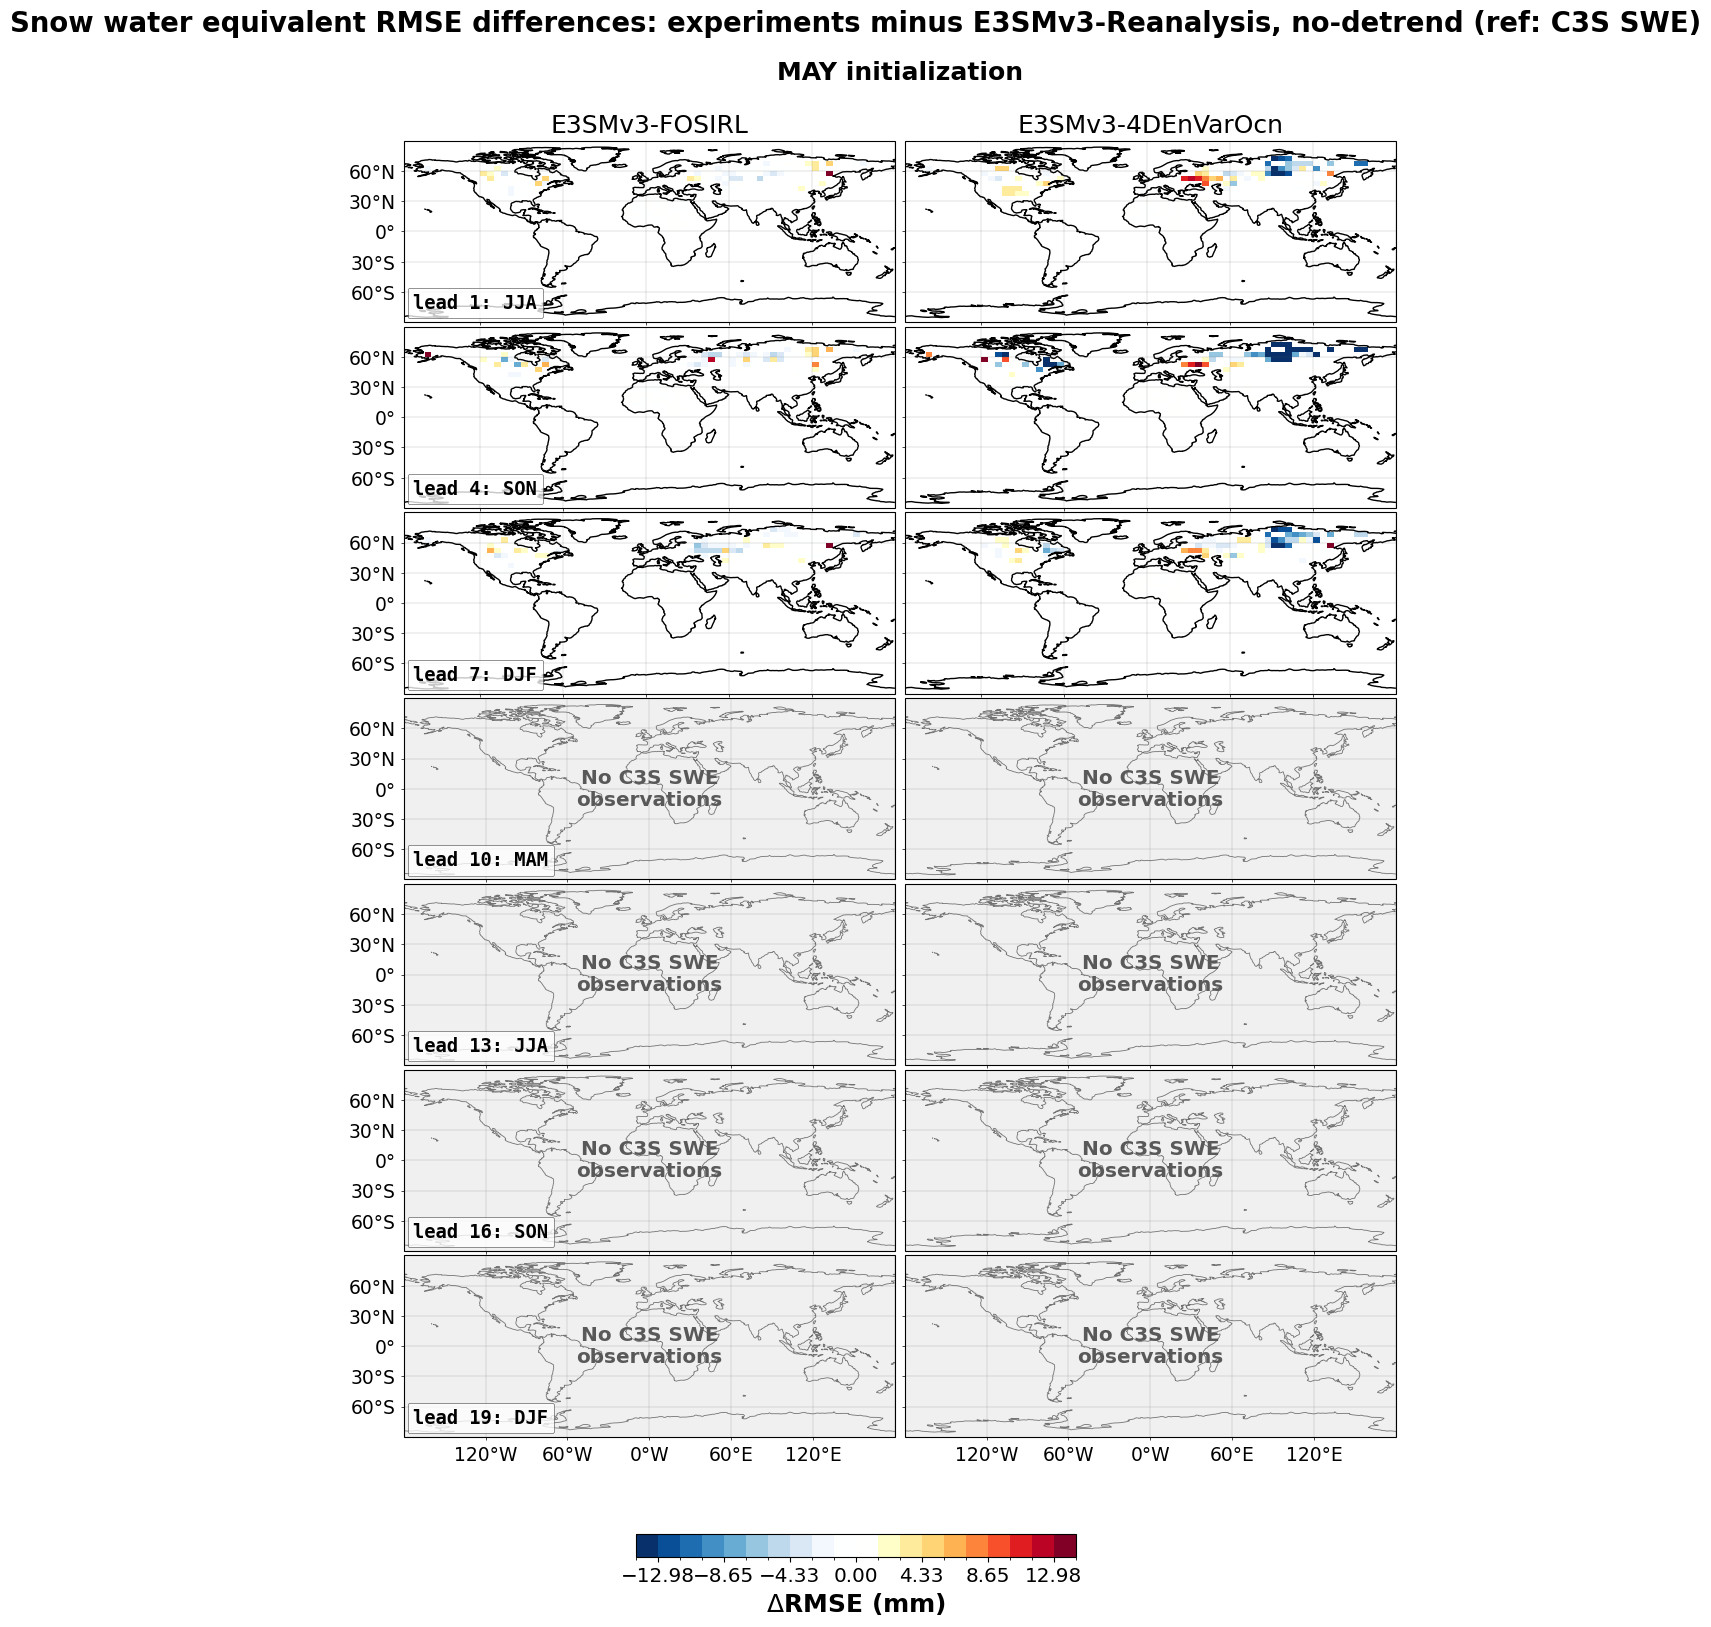

Saved difference figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_rmse_compare_h2osno_rmse_difference_global_init11.png


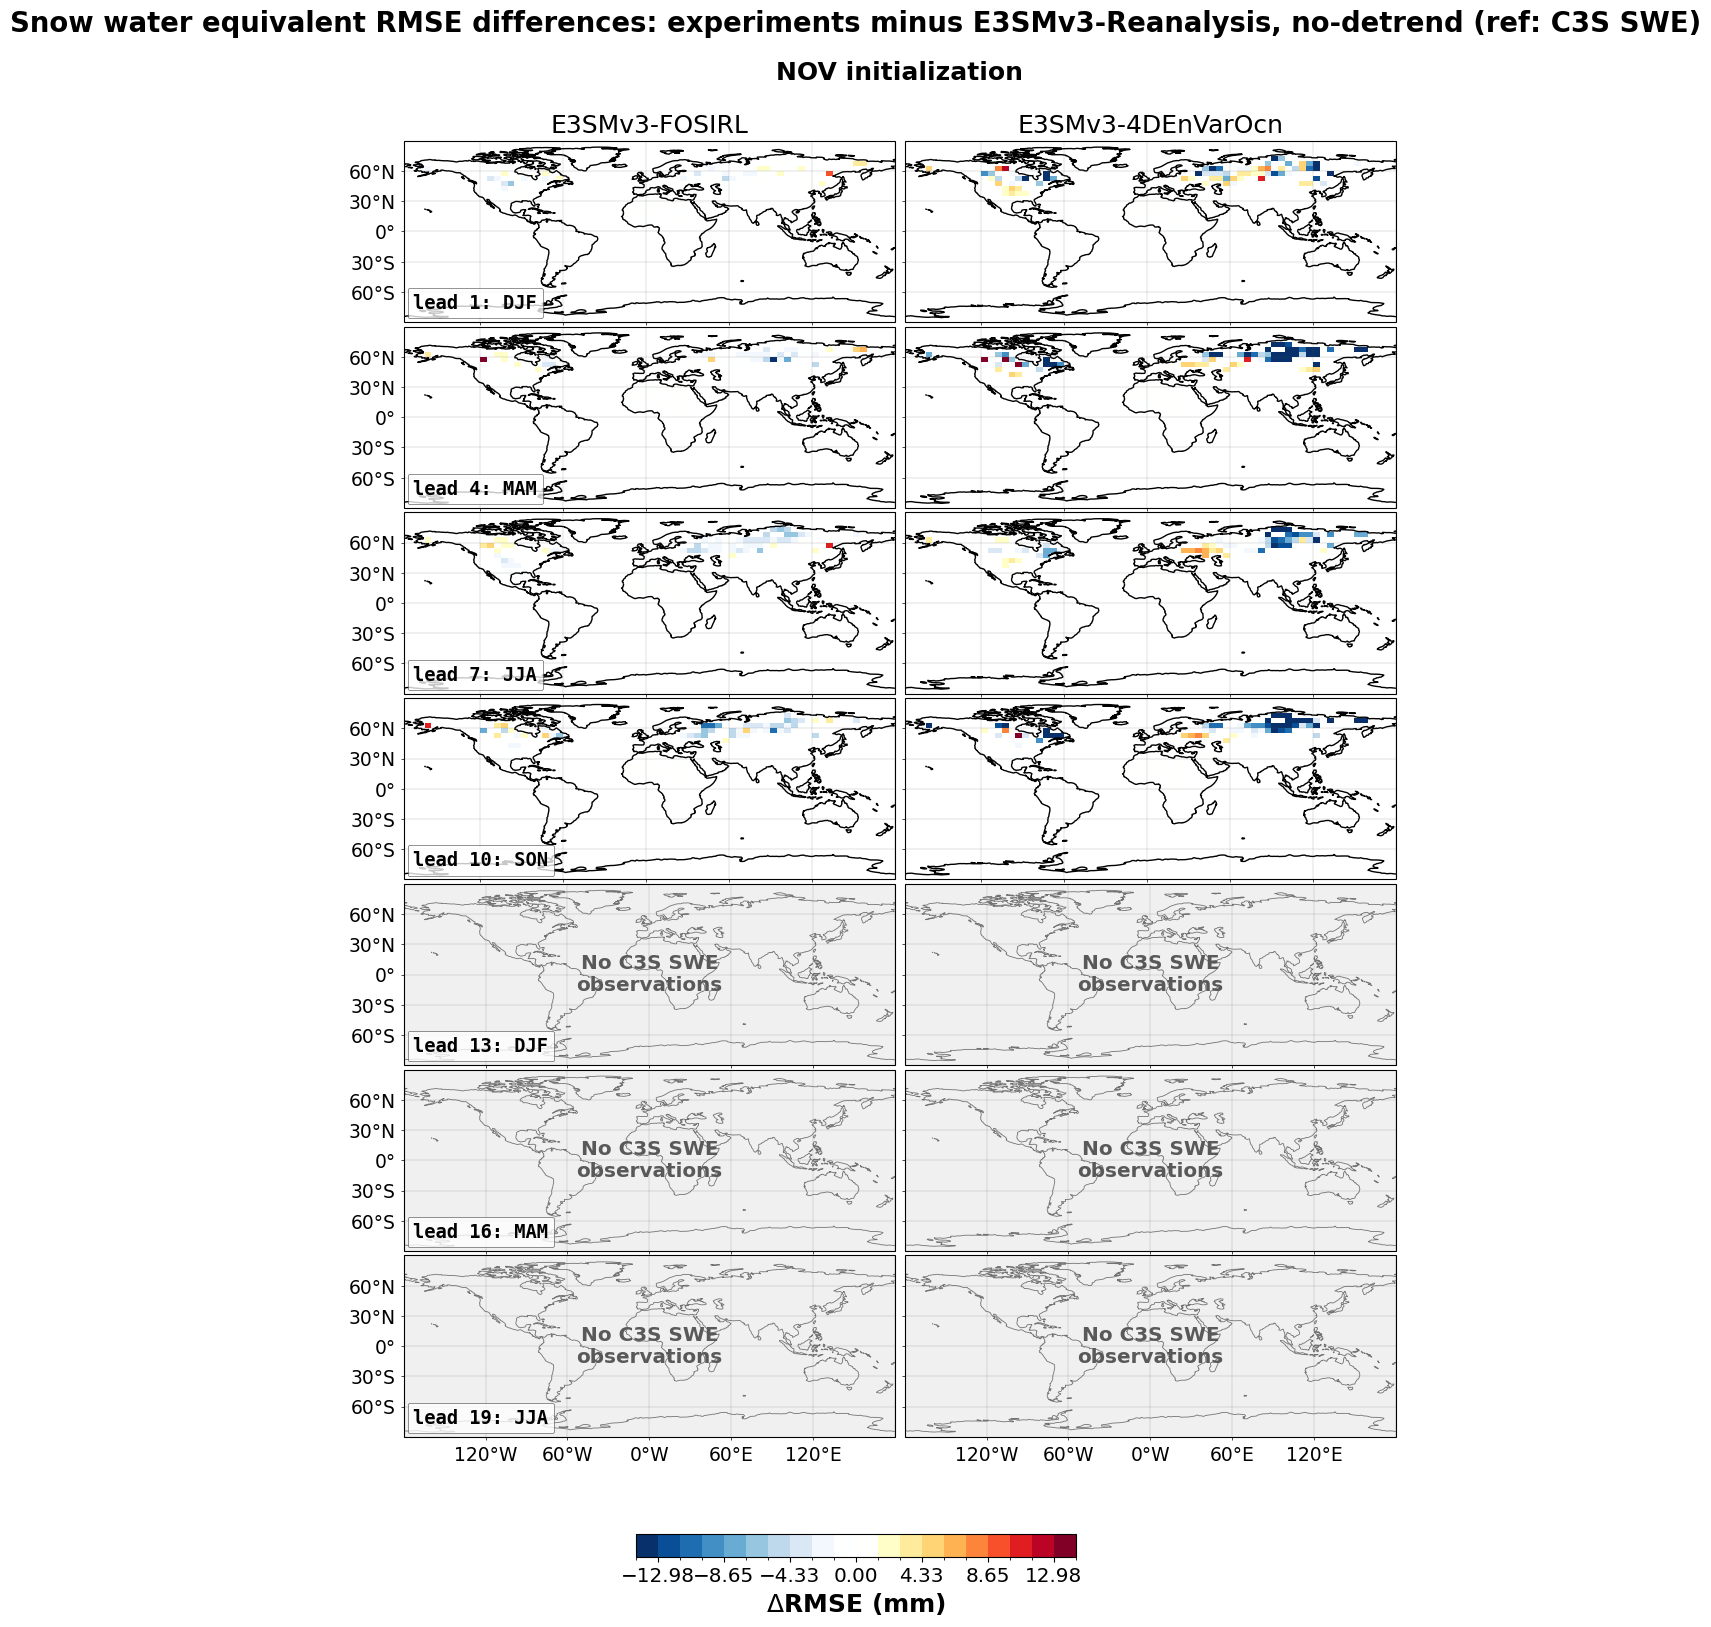

In [29]:
if DIRECT_RMSE_UNDEFINED:
    print(SKIP_MESSAGE)
else:
    DIFF_PLOT = FIGURE_SETTINGS["difference"]

    difference_cases = [
        case_name for case_name in E3SM_CASES
        if case_name != reference_model
    ]
    if not difference_cases:
        raise RuntimeError("At least two E3SM cases are required for direct-RMSE differences")

    difference_column_specs = [
        (init_month, case_name)
        for init_month in RUN["init_months"]
        for case_name in difference_cases
        if init_month in direct_rmse_diff_by_case_month.get(case_name, {})
    ]
    difference_months = list(dict.fromkeys(
        init_month for init_month, _ in difference_column_specs
    ))
    if not difference_column_specs or not FULL_SEASONAL_LEADS:
        raise RuntimeError(
            "No common experiment/reference month/lead combinations are available "
            "for the direct-RMSE differences"
        )

    # Same reasoning as the RMSE map cell: direct-RMSE differences have no fixed
    # natural scale, so the symmetric color range is computed from the actual data.
    finite_diff_values = np.concatenate([
        np.asarray(da.values, dtype=float)[np.isfinite(da.values)]
        for da in (
            direct_rmse_diff_by_case_month[case_name][init_month]["rmse_diff"]
            for init_month, case_name in difference_column_specs
        )
    ])
    if finite_diff_values.size == 0:
        raise RuntimeError("No finite direct-RMSE differences are available to plot.")
    auto_diff_bound = max(float(np.nanpercentile(np.abs(finite_diff_values), 95)), 1e-6)
    auto_diff_interval = auto_diff_bound / 10.0
    DIFF_PLOT = dict(
        DIFF_PLOT, color_min=-auto_diff_bound, color_max=auto_diff_bound,
        color_interval=auto_diff_interval, color_cutoff=auto_diff_bound / 2.0,
    )
    print(f"Auto color range for direct-RMSE difference ({field}): -{auto_diff_bound:.4g} to {auto_diff_bound:.4g}")

    # One figure per initialization month (as in 1c_atm/1c_ocn); the color range
    # above is shared so May and November stay directly comparable.
    all_difference_column_specs = difference_column_specs
    for plot_month in list(difference_months):
        difference_column_specs = [
            spec for spec in all_difference_column_specs if spec[0] == plot_month
        ]
        difference_months = [plot_month]
        nrows = len(FULL_SEASONAL_LEADS)
        ncols = len(difference_column_specs)
        section_gap = DIFF_PLOT["section_gap"] if len(difference_months) > 1 else 0.0
        fig = plt.figure(figsize=(
            DIFF_PLOT["column_width"] * ncols + DIFF_PLOT["extra_width"], DIFF_PLOT["figsize"][1]
        ))
        mappable = None
        for row in range(nrows):
            for col, (init_month, case_name) in enumerate(difference_column_specs):
                subplot = row * ncols + col + 1
                lead = FULL_SEASONAL_LEADS[row]
                skill = direct_rmse_by_case_month[case_name][init_month]
                title = case_display_names.get(case_name, case_name) if row == 0 else ""
                difference = direct_rmse_diff_by_case_month[case_name][init_month]["rmse_diff"]
                if lead in difference.L.values:
                    ax, mappable = maps.map_pcolor_global_subplot(
                        fig, difference.sel(L=lead), skill.lon, skill.lat,
                        DIFF_PLOT["color_interval"], DIFF_PLOT["color_min"], DIFF_PLOT["color_max"],
                        title, nrows, ncols, subplot, projection,
                        cmap=DIFF_PLOT["cmap"], cutoff=DIFF_PLOT["color_cutoff"],
                        fontsize=DIFF_PLOT["font_size"],
                    )
                else:
                    ax = add_missing_map_panel(
                        fig, nrows=nrows, ncols=ncols, subplot=subplot, title=title,
                        message=f"No {REFERENCE_DISPLAY_NAME}\nobservations",
                        font_size=DIFF_PLOT["font_size"],
                    )
                style_global_map_axis(
                    ax, row=row, column=col, nrows=nrows,
                    label_size=(
                        DIFF_PLOT["font_size"] * DIFF_PLOT["axis_label_font_scale"]
                    ),
                    style=MAP_STYLE,
                )
                if col == 0 or difference_column_specs[col - 1][0] != init_month:
                    display_lead = int(lead) - 2
                    add_lead_badge(
                        ax, f"lead {display_lead}: {seasonal_label(init_month, display_lead)}",
                        font_size=(
                            DIFF_PLOT["font_size"] * DIFF_PLOT["lead_label_font_scale"]
                        ),
                    )

        difference_title = DIFF_PLOT["title_template"].format(
            variable=VARIABLE_DIFFERENCE_CONTEXT,
            reference=REFERENCE_DISPLAY_NAME,
            control=case_display_names[reference_model],
            trend="no-detrend",
        )
        difference_caption = (
            f"RMSE differences (experiment minus "
            f"{case_display_names[reference_model]}) for {VARIABLE_CAPTION_NAME}, "
            f"by seasonal lead, {init_month_names.get(plot_month, plot_month)} initialization; "
            f"initializations {PROCESSING_YEARS[0]}\u2013{PROCESSING_YEARS[1]}."
        )
        fig.suptitle(
            difference_title,
            fontsize=DIFF_PLOT["font_size"] * DIFF_PLOT["title_font_scale"],
            fontweight=DIFF_PLOT["font_weight"], y=DIFF_PLOT["title_y"],
        )
        layout_left, layout_bottom, layout_right, layout_top = DIFF_PLOT["layout_edges"]
        layout_right -= section_gap * (len(difference_months) - 1)
        fig.tight_layout(
            rect=(layout_left, layout_bottom, layout_right, layout_top),
            pad=DIFF_PLOT["layout_pad"],
            h_pad=DIFF_PLOT["layout_h_pad"],
            w_pad=DIFF_PLOT["layout_w_pad"],
        )
        fig.subplots_adjust(
            top=DIFF_PLOT["subplot_top"],
            bottom=DIFF_PLOT["subplot_bottom"],
            hspace=DIFF_PLOT["subplot_hspace"],
            wspace=DIFF_PLOT["subplot_wspace"],
        )

        # Separate and label initialization-month column groups.
        for group_index, init_month in enumerate(difference_months):
            if group_index == 0:
                continue
            month_cols = [
                col for col, (month, _) in enumerate(difference_column_specs)
                if month == init_month
            ]
            for row in range(nrows):
                for col in month_cols:
                    ax = fig.axes[row * ncols + col]
                    pos = ax.get_position()
                    ax.set_position([
                        pos.x0 + group_index * section_gap,
                        pos.y0, pos.width, pos.height,
                    ])

        month_header_y = DIFF_PLOT["month_header_y"]
        for init_month in difference_months:
            cols = [
                col for col, (month, _) in enumerate(difference_column_specs)
                if month == init_month
            ]
            left = min(fig.axes[col].get_position().x0 for col in cols)
            right = max(fig.axes[col].get_position().x1 for col in cols)
            fig.text(
                (left + right) / 2, month_header_y,
                f"{init_month_names.get(init_month, init_month)} initialization",
                ha="center", va="bottom",
                fontsize=DIFF_PLOT["font_size"] * DIFF_PLOT["month_header_font_scale"],
                fontweight=DIFF_PLOT["font_weight"],
            )

        for left_month, right_month in zip(difference_months, difference_months[1:]):
            left_cols = [
                col for col, (month, _) in enumerate(difference_column_specs)
                if month == left_month
            ]
            right_cols = [
                col for col, (month, _) in enumerate(difference_column_specs)
                if month == right_month
            ]
            divider_x = (
                max(fig.axes[col].get_position().x1 for col in left_cols)
                + min(fig.axes[col].get_position().x0 for col in right_cols)
            ) / 2
            fig.add_artist(plt.Line2D(
                [divider_x, divider_x],
                [DIFF_PLOT["divider_y0"], DIFF_PLOT["divider_y1"]],
                transform=fig.transFigure, color=DIFF_PLOT["divider_color"],
                linewidth=DIFF_PLOT["divider_linewidth"],
            ))
        colorbar_ax = fig.add_axes(DIFF_PLOT["colorbar_rect"])
        colorbar = fig.colorbar(
            mappable, cax=colorbar_ax, orientation=DIFF_PLOT["colorbar_orientation"]
        )
        field_units = reference_cfg.get("output_units", "")
        diff_colorbar_label_with_units = (
            f"{DIFF_PLOT['colorbar_label']} ({field_units})" if field_units else DIFF_PLOT["colorbar_label"]
        )
        colorbar.set_label(
            diff_colorbar_label_with_units,
            fontsize=DIFF_PLOT["font_size"],
            fontweight=DIFF_PLOT["font_weight"],
        )
        colorbar.ax.tick_params(
            labelsize=(
                DIFF_PLOT["font_size"] * DIFF_PLOT["colorbar_tick_font_scale"]
            )
        )

        difference_path = FIGURE_OUTDIR / DIFF_PLOT["filename"].format(init_month=plot_month)
        mov.save_figure(
            fig, difference_path, mode="", metric="rmse_compare",
            title=difference_title,
            caption=difference_caption,
            dpi=DIFF_PLOT["dpi"],
        )
        print("Saved difference figure:", difference_path)
        plt.show()

## Cleanup

Prepared inputs, skills, and figures remain on disk. Run this after completion or an
interrupted calculation to close staged datasets, the Dask client, and its cluster.


In [30]:
close_notebook_resources(globals())
print("Closed land-workflow datasets and Dask resources.")


Closed land-workflow datasets and Dask resources.
